### 1. Data Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

# Load your datasets here

train_file_path = r"C:\Users\olufe\Preliminary_Preprocessing\dataset\dataset_train_0.csv"
test_file_path = r"C:\Users\olufe\Preliminary_Preprocessing\dataset\dataset_test_0.csv"

train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Handling Class Imbalance
smote = SMOTE()
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)


### 2. Model Training and Cross-validation

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
evaluation_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring='accuracy')
    evaluation_results[name] = scores

# Output results
for model_name, scores in evaluation_results.items():
    print(f"{model_name}: Accuracy: {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")


Logistic Regression: Accuracy: 0.69 (+/- 0.01)
Decision Tree: Accuracy: 0.70 (+/- 0.02)
Random Forest: Accuracy: 0.82 (+/- 0.02)
Gradient Boosting: Accuracy: 0.89 (+/- 0.01)
Neural Network: Accuracy: 0.80 (+/- 0.02)


### 1. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Splitting the balanced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_train_balanced, y_train_balanced, test_size=0.3, random_state=42)

### 2. Model Training

In [5]:
# Train the models on the training set
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

# Fit the models
for name, model in models.items():
    model.fit(X_train, y_train)


### 3. Performance Evaluation

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.54      0.62      0.58       165
           1       0.92      0.81      0.87       178
           2       0.52      0.43      0.47       197
           3       0.78      0.89      0.83       185
           4       0.38      0.38      0.38       155
           5       0.95      0.99      0.97       188

    accuracy                           0.69      1068
   macro avg       0.68      0.69      0.68      1068
weighted avg       0.69      0.69      0.69      1068



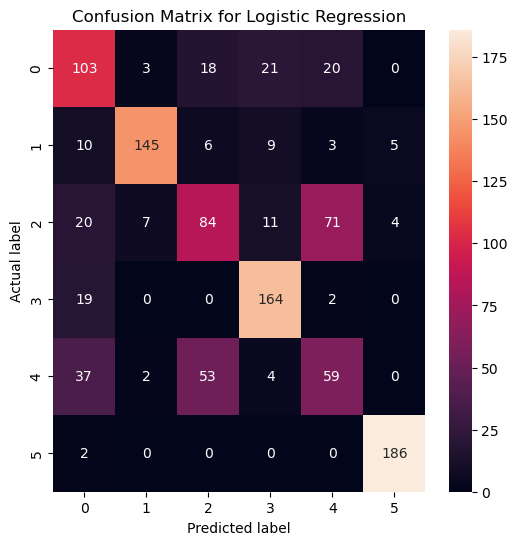

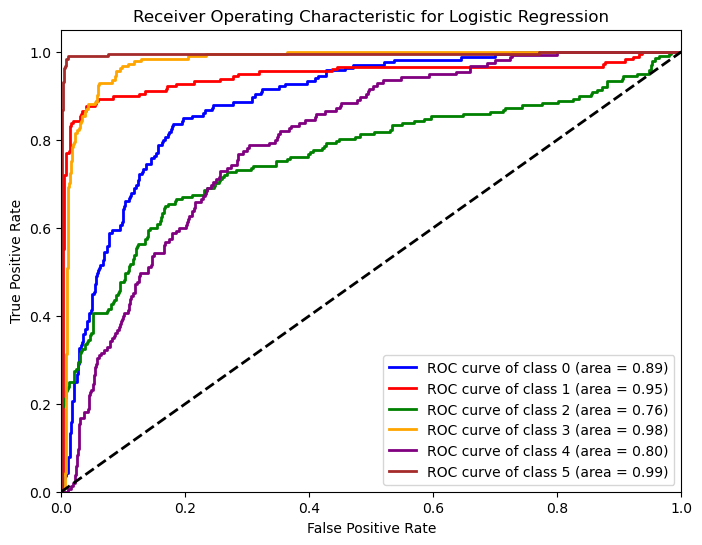

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.53      0.61      0.57       165
           1       0.79      0.67      0.73       178
           2       0.71      0.60      0.65       197
           3       0.70      0.70      0.70       185
           4       0.78      0.84      0.81       155
           5       0.78      0.87      0.83       188

    accuracy                           0.71      1068
   macro avg       0.72      0.72      0.71      1068
weighted avg       0.72      0.71      0.71      1068



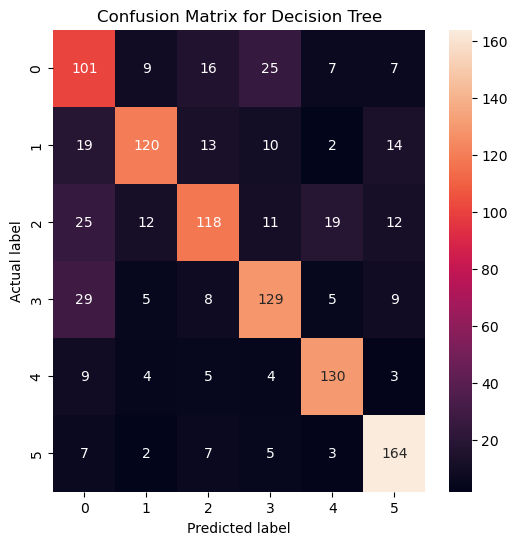

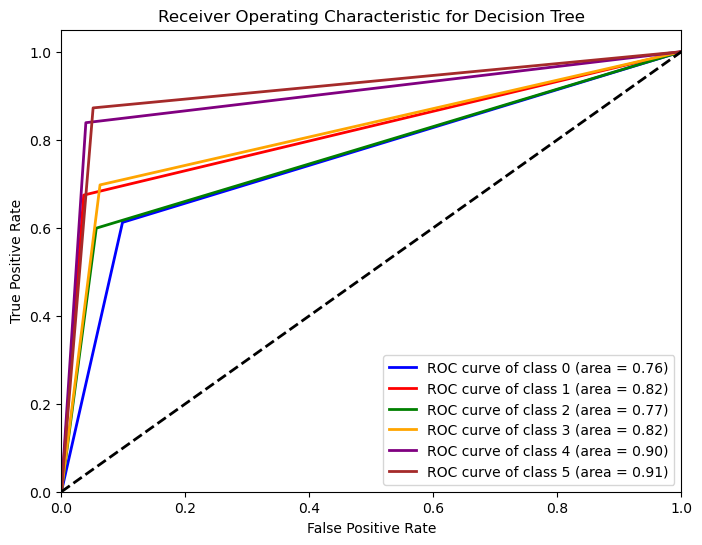

Model: Random Forest
              precision    recall  f1-score   support

           0       0.57      0.68      0.62       165
           1       0.86      0.71      0.78       178
           2       0.90      0.74      0.81       197
           3       0.87      0.85      0.86       185
           4       0.82      0.98      0.89       155
           5       0.92      0.95      0.93       188

    accuracy                           0.82      1068
   macro avg       0.82      0.82      0.82      1068
weighted avg       0.83      0.82      0.82      1068



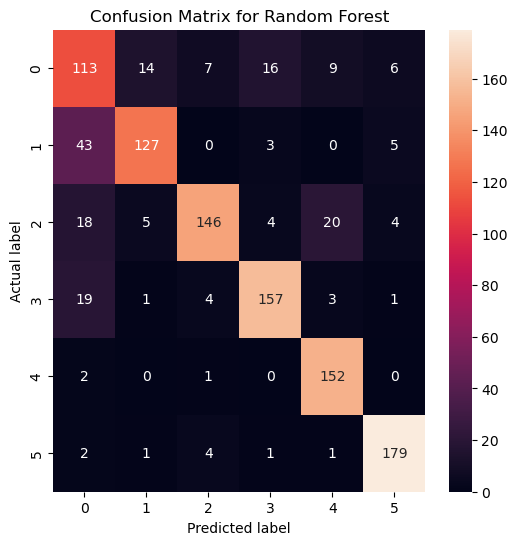

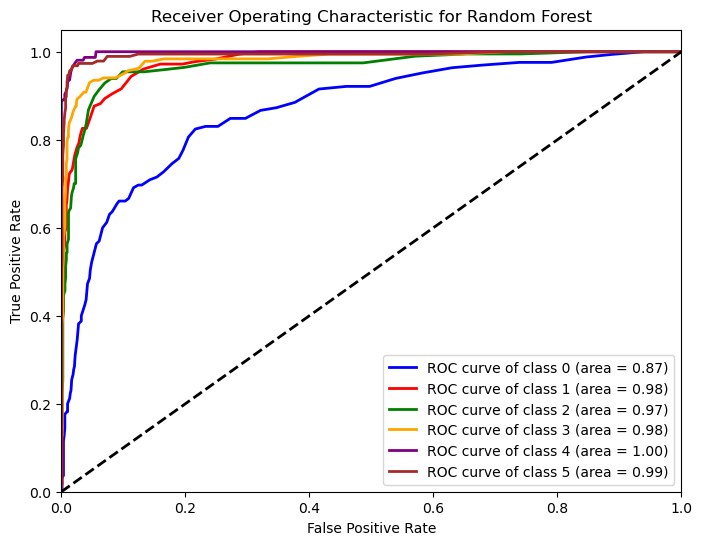

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       165
           1       0.98      0.85      0.91       178
           2       0.92      0.86      0.89       197
           3       0.91      0.89      0.90       185
           4       0.98      0.90      0.94       155
           5       0.95      0.95      0.95       188

    accuracy                           0.89      1068
   macro avg       0.90      0.89      0.89      1068
weighted avg       0.90      0.89      0.89      1068



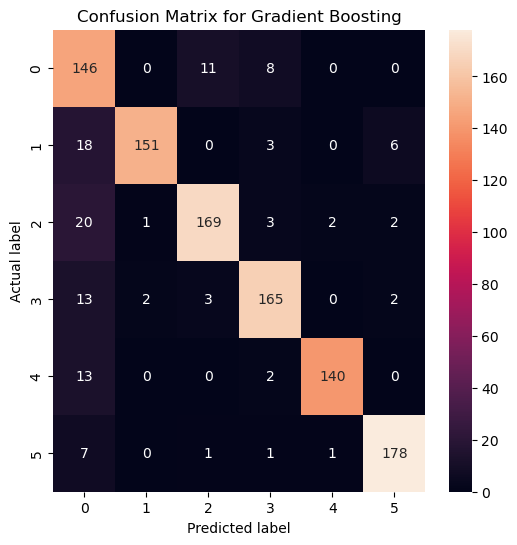

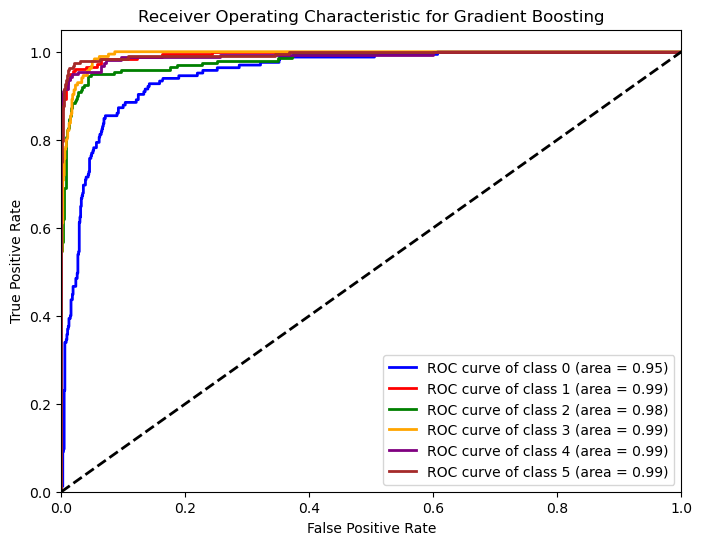

Model: Neural Network
              precision    recall  f1-score   support

           0       0.60      0.75      0.66       165
           1       0.96      0.85      0.90       178
           2       0.78      0.65      0.71       197
           3       0.80      0.89      0.84       185
           4       0.75      0.68      0.72       155
           5       0.97      0.98      0.98       188

    accuracy                           0.81      1068
   macro avg       0.81      0.80      0.80      1068
weighted avg       0.81      0.81      0.81      1068



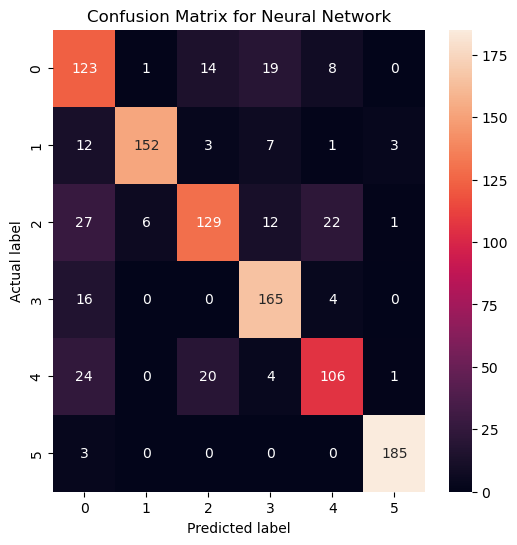

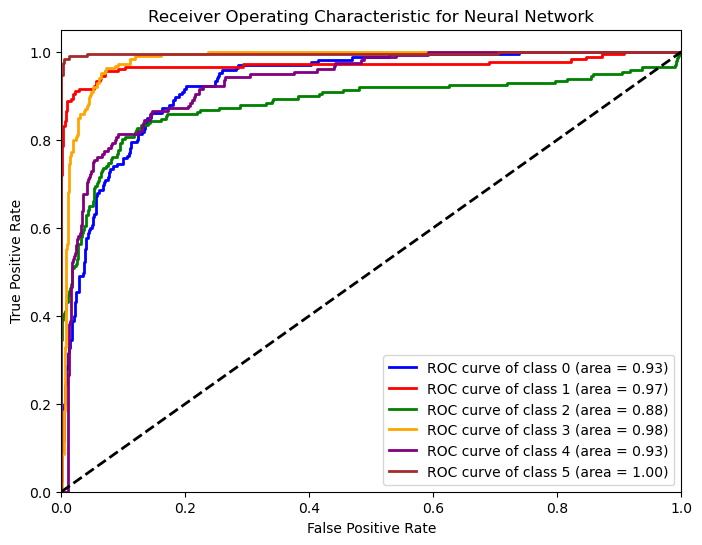

In [10]:
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns

# Binarize the output classes for ROC computation
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train_balanced))

# Evaluate each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Print the classification report
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()
    
    # ROC Curve for each class
    n_classes = y_test_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plotting ROC Curve for each class
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
    plt.figure(figsize=(8, 6))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic for {name}')
    plt.legend(loc="lower right")
    plt.show()
